<a href="https://colab.research.google.com/github/kiyara17777/Drdo-background-bias-clip/blob/main/DRDO_INTERNSHIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEEK 1


In [ ]:
!pip uninstall -y rembg numpy pillow opencv-python opencv-python-headless
!pip install numpy pillow opencv-python-headless rembg onnxruntime requests pandas datasets huggingface_hub


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
import numpy as np
import cv2
from rembg import remove
from PIL import Image

print("All libraries loaded successfully")


All libraries loaded successfully


#STEP 1: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# STEP 2: Imports (no pip)

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import requests
from datasets import load_dataset
from itertools import islice
from PIL import Image
from rembg import remove


# STEP 3: Paths

In [ ]:
BASE = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1"
ORIG_DIR = f"{BASE}/original"
FG_DIR   = f"{BASE}/foreground"
BG_DIR   = f"{BASE}/background"
MASK_DIR = f"{BASE}/masks"

for d in [ORIG_DIR, FG_DIR, BG_DIR, MASK_DIR]:
    os.makedirs(d, exist_ok=True)

In [ ]:
# --- STEP X: Check existing processed images

def count_images(folder):
    return len([f for f in os.listdir(folder) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

fg_count = count_images(FG_DIR)
bg_count = count_images(BG_DIR)
mask_count = count_images(MASK_DIR)

print(f"Foreground images: {fg_count}")
print(f"Background images: {bg_count}")
print(f"Masks: {mask_count}")

# Optional: total processed records
total_processed = min(fg_count, bg_count, mask_count)
print(f"Total fully processed images: {total_processed}")



Foreground images: 8727
Background images: 8727
Masks: 8727
Total fully processed images: 8727


#STEP 4: Load dataset (streaming)

In [ ]:
ds = load_dataset("laion/relaion400m", split="train", streaming=True)


Resolving data files:   0%|          | 0/128 [00:00<?, ?it/s]

#STEP 5: Foreground extraction (CLEAN)

In [ ]:
# STEP 5: Foreground extraction (FIXED COLOR)

def extract_foreground(image_bgr):
    # Convert BGR → RGB for rembg
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(image_rgb)

    fg_pil = remove(pil_img)
    fg = np.array(fg_pil)

    alpha = fg[:, :, 3]
    mask = (alpha > 128).astype(np.uint8) * 255

    fg_rgb = fg[:, :, :3]

    # ✅ FIX: convert back RGB → BGR before saving
    fg_bgr = cv2.cvtColor(fg_rgb, cv2.COLOR_RGB2BGR)

    mask = cv2.medianBlur(mask, 5)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

    return fg_bgr, mask



#STEP 6: Background extraction (PROPER)

In [ ]:
def extract_background(image, mask):
    bg = image.copy()
    bg[mask == 255] = 0
    return bg


#STEP 7: Resize function

In [ ]:
def resize_image(img, size=256):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(img, (new_w, new_h))

#STEP 8: Process images

In [ ]:
records = []
MAX_IMAGES = 15000   # 👈 only for documentation

for sample in islice(ds, MAX_IMAGES):
    try:
        url = sample["url"]
        img_id = sample["key"]

        r = requests.get(url, timeout=10)
        img = np.asarray(bytearray(r.content), dtype=np.uint8)
        img = cv2.imdecode(img, cv2.IMREAD_COLOR)
        if img is None:
            continue

        if min(img.shape[:2]) < 180:
            continue

        img = resize_image(img)

        # SAVE ORIGINAL
        orig_path = f"{ORIG_DIR}/{img_id}.jpg"
        cv2.imwrite(orig_path, img)

        fg, mask = extract_foreground(img)
        bg = extract_background(img, mask)

        fg_path = f"{FG_DIR}/{img_id}_fg.png"
        bg_path = f"{BG_DIR}/{img_id}_bg.png"
        mask_path = f"{MASK_DIR}/{img_id}_mask.png"

        cv2.imwrite(fg_path, fg)
        cv2.imwrite(bg_path, bg)
        cv2.imwrite(mask_path, mask)

        records.append({
            "id": img_id,
            "original": orig_path,
            "fg": fg_path,
            "bg": bg_path,
            "mask": mask_path
        })

        print("Saved:", img_id)

    except:
        continue

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Saved: 9048
Saved: 6649
Saved: 102
Saved: 9286
Saved: 9030
Saved: 7333
Saved: 8802
Saved: 545
Saved: 4248
Saved: 3406
Saved: 6481
Saved: 5265
Saved: 5174
Saved: 5238
Saved: 6976
Saved: 3900
Saved: 8627
Saved: 722
Saved: 2195
Saved: 6891
Saved: 5495
Saved: 5722
Saved: 8353
Saved: 7238
Saved: 1327
Saved: 1443
Saved: 6539
Saved: 8112
Saved: 4446
Saved: 2342
Saved: 6050
Saved: 6528
Saved: 237
Saved: 555
Saved: 4902
Saved: 4965
Saved: 9224
Saved: 8897
Saved: 2931
Saved: 5703
Saved: 7761
Saved: 9786
Saved: 5106
Saved: 9613
Saved: 772
Saved: 365
Saved: 9503
Saved: 6754
Saved: 784
Saved: 3584
Saved: 3223
Saved: 600
Saved: 7885
Saved: 9514
Saved: 4256
Saved: 7840
Saved: 6188
Saved: 7504
Saved: 3676
Saved: 750
Saved: 4747
Saved: 2601
Saved: 6312
Saved: 6099
Saved: 1090
Saved: 705
Saved: 9490
Saved: 2832
Saved: 5967
Saved: 9153
Saved: 4345
Saved: 916
Saved: 2926
Saved: 870
Saved: 5031
Saved: 1735
Saved: 6212
Saved: 5468
Saved: 478
Saved: 6781
Saved: 6072
Saved: 8532
Saved: 8318
Saved: 8344
Saved:

#STEP 9: Save CSV

In [ ]:
df = pd.DataFrame(records)
csv_path = f"{BASE}/fg_bg_masks.csv"
df.to_csv(csv_path, index=False)

print("Done. Images:", len(df))
print("CSV:", csv_path)


Done. Images: 8727
CSV: /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1/fg_bg_masks.csv


In [ ]:
import os
import pandas as pd

BASE = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1"
ORIG_DIR = f"{BASE}/original"
FG_DIR = f"{BASE}/foreground"
BG_DIR = f"{BASE}/background"
MASK_DIR = f"{BASE}/masks"

records = []

for fname in os.listdir(FG_DIR):
    if fname.endswith("_fg.png"):
        img_id = fname.replace("_fg.png", "")

        fg_path = f"{FG_DIR}/{img_id}_fg.png"
        bg_path = f"{BG_DIR}/{img_id}_bg.png"
        mask_path = f"{MASK_DIR}/{img_id}_mask.png"
        orig_path = f"{ORIG_DIR}/{img_id}.jpg"

        if os.path.exists(bg_path) and os.path.exists(mask_path):
            records.append({
                "id": img_id,
                "original": orig_path if os.path.exists(orig_path) else "",
                "fg": fg_path,
                "bg": bg_path,
                "mask": mask_path
            })

df = pd.DataFrame(records)
out_csv = f"{BASE}/fg_bg_masks.csv"
df.to_csv(out_csv, index=False)

print("Rebuilt CSV with rows:", len(df))
print(df.head())


Rebuilt CSV with rows: 8727
     id                                           original  \
0  4835  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
1  2690  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
2  3224  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
3  6602  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
4  7562  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   

                                                  fg  \
0  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
1  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
2  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
3  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
4  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   

                                                  bg  \
0  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
1  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
2  /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/W...   
3  /content/drive/MyDrive/DRDO_Weekly_

# WEEK 2

#1.FOLDER SETUP

In [ ]:
import os

WEEK2 = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_2"
os.makedirs(f"{WEEK2}/embeddings", exist_ok=True)
os.makedirs(f"{WEEK2}/similarity", exist_ok=True)
os.makedirs(f"{WEEK2}/plots", exist_ok=True)

print("Week 2 folders created")



Week 2 folders created


#2.Install & import libraries

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [ ]:
import os

base = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1"
print(os.listdir(base))


['foreground', 'background', 'masks', 'original', 'fg_bg_masks.gsheet', 'fg_bg_masks.csv']


In [ ]:
import os

csv_path = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1/fg_bg_masks.csv"
print("File size:", os.path.getsize(csv_path))


File size: 2121685


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_2"))


['embeddings', 'similarity', 'plots', 'findings.txt']


In [ ]:
print(os.listdir("/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_2/similarity"))


['bg_bg_similarity.npy']


#3.Load Week-1 CSV

In [ ]:
csv_path = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1/fg_bg_masks.csv"
df = pd.read_csv(csv_path)
print("Total clean images:", len(df))

Total clean images: 8727


#4. Load pretrained ResNet-18 (feature extractor)
(Device & ResNet model)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet = models.resnet18(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
resnet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

#5.Image preprocessing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

#6.Embedding extraction function

In [ ]:
def get_embedding(image_path):
    img = Image.open(image_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = resnet(img)
    return emb.squeeze().cpu().numpy()

#7. Extract BACKGROUND embeddings only


In [ ]:
bg_embeddings = []
batch_size = 50

for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size]
    for _, row in batch.iterrows():
        try:
            bg_embeddings.append(get_embedding(row["bg"]))
        except:
            print("Skipped:", row["bg"])
    print(f"Processed {i+len(batch)} / {len(df)} images")

bg_embeddings = np.array(bg_embeddings)
print("BG embeddings shape:", bg_embeddings.shape)

Processed 50 / 8727 images
Processed 100 / 8727 images
Processed 150 / 8727 images
Processed 200 / 8727 images
Processed 250 / 8727 images
Processed 300 / 8727 images
Processed 350 / 8727 images
Processed 400 / 8727 images
Processed 450 / 8727 images
Processed 500 / 8727 images
Processed 550 / 8727 images
Processed 600 / 8727 images
Processed 650 / 8727 images
Processed 700 / 8727 images
Processed 750 / 8727 images
Processed 800 / 8727 images
Processed 850 / 8727 images
Processed 900 / 8727 images
Processed 950 / 8727 images
Processed 1000 / 8727 images
Processed 1050 / 8727 images
Processed 1100 / 8727 images
Processed 1150 / 8727 images
Processed 1200 / 8727 images
Processed 1250 / 8727 images
Processed 1300 / 8727 images
Processed 1350 / 8727 images
Processed 1400 / 8727 images
Processed 1450 / 8727 images
Processed 1500 / 8727 images
Processed 1550 / 8727 images
Processed 1600 / 8727 images
Processed 1650 / 8727 images
Processed 1700 / 8727 images
Processed 1750 / 8727 images
Proce

#8. Save background embeddings

In [ ]:
np.save(f"{WEEK2}/embeddings/bg_embeddings.npy", bg_embeddings)
print("Background embeddings saved")


Background embeddings saved


#9.Compute BACKGROUND–BACKGROUND cosine similarity

In [ ]:
bg_similarity = cosine_similarity(bg_embeddings, bg_embeddings)

np.save(f"{WEEK2}/similarity/bg_bg_similarity.npy", bg_similarity)

print("BG–BG similarity matrix shape:", bg_similarity.shape)


BG–BG similarity matrix shape: (8727, 8727)


#10. Visualize BG–BG similarity


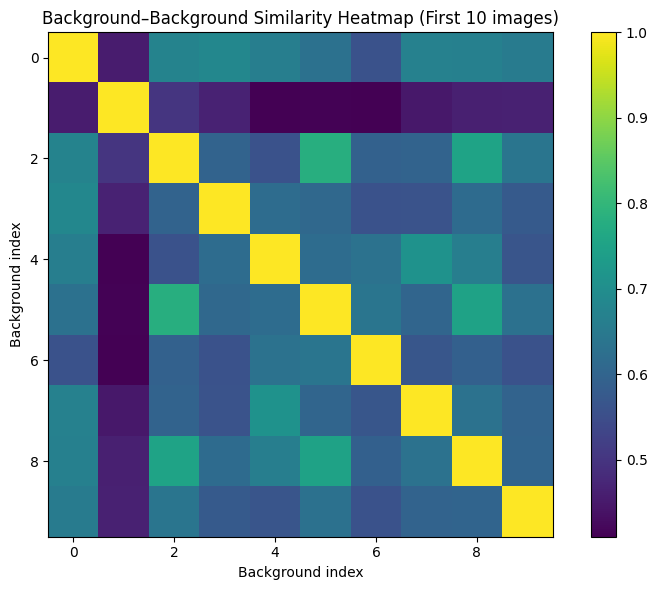

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(bg_similarity[:10, :10])
plt.colorbar()
plt.title("Background–Background Similarity Heatmap (First 10 images)")
plt.xlabel("Background index")
plt.ylabel("Background index")
plt.tight_layout()
plt.savefig(f"{WEEK2}/plots/bg_bg_similarity_heatmap.png")
plt.show()

In [ ]:
print(bg_similarity.shape)
print(len(df))


(8727, 8727)
8727


In [ ]:
summary = """
Week 2 Summary:

- Used pretrained ResNet-18 as a feature extractor
- Generated embeddings for background images only
- Computed cosine similarity among all background embeddings
- Background similarity matrix saved for use in background replacement (Week-3)
"""

with open(f"{WEEK2}/findings.txt", "w") as f:
    f.write(summary)

print("Week 2 findings saved")


Week 2 findings saved


# WEEK 3

#1.Imports & Folder Setup

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

#2.FOLDER SETUP

In [ ]:
BASE_W3 = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_3_CLEAN"
BG_CHANGED_FOLDER = os.path.join(BASE_W3, "BG_CHANGED")
FINDINGS_FOLDER = os.path.join(BASE_W3, "Interesting_Findings")

os.makedirs(BG_CHANGED_FOLDER, exist_ok=True)
os.makedirs(FINDINGS_FOLDER, exist_ok=True)

print("Created:", BG_CHANGED_FOLDER)
print("Exists?", os.path.exists(BG_CHANGED_FOLDER))


Created: /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_3_CLEAN/BG_CHANGED
Exists? True


#3.Load Week-1 CSV

In [ ]:
CSV_PATH = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_1/fg_bg_masks.csv"
BG_SIM_PATH = "/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_2/similarity/bg_bg_similarity.npy"

df = pd.read_csv(CSV_PATH)
bg_similarity = np.load(BG_SIM_PATH)

print("Images:", len(df))
print("BG similarity shape:", bg_similarity.shape)

assert bg_similarity.shape[0] == len(df)
assert bg_similarity.shape[1] == len(df)



Images: 8727
BG similarity shape: (8727, 8727)


#   4.Device + ResNet Feature Extractor

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [ ]:
resnet = models.resnet18(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.to(device)
resnet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

## 5. Embedding Function

In [ ]:
def get_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = resnet(img)
    return emb.squeeze().cpu().numpy()


#6.Background Replacement

In [ ]:
THRESH = 0.90
BATCH_SIZE = 20
START_IDX = 20   # change to 20,40,... to resume

meta_path = f"{BASE_W3}/bg_changed_metadata.csv"

records = []
if os.path.exists(meta_path):
    records = pd.read_csv(meta_path).to_dict("records")

os.makedirs(BG_CHANGED_FOLDER, exist_ok=True)

existing_files = [
    f.replace("_clean.png", "")
    for f in os.listdir(BG_CHANGED_FOLDER)
    if f.endswith("_clean.png")
]
processed_ids = set(existing_files)

end_idx = min(START_IDX + BATCH_SIZE, len(df))

for i in tqdm(range(START_IDX, end_idx)):
    row = df.iloc[i]

    if str(row["id"]) in processed_ids:
        continue

    fg = cv2.imread(row["fg"])
    mask = cv2.imread(row["mask"], cv2.IMREAD_GRAYSCALE)
    if fg is None or mask is None:
        continue

    valid_idxs = np.where(bg_similarity[i] < THRESH)[0]
    if len(valid_idxs) == 0:
        valid_idxs = [j for j in range(len(df)) if j != i]

    chosen_idx = random.choice(valid_idxs)
    bg = cv2.imread(df.iloc[chosen_idx]["bg"])
    if bg is None:
        continue

    bh, bw = bg.shape[:2]
    fh, fw = fg.shape[:2]

    scale = min((0.7 * bw) / fw, (0.7 * bh) / fh)
    new_w, new_h = int(fw * scale), int(fh * scale)

    fg_resized = cv2.resize(fg, (new_w, new_h))
    mask_resized = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    x_offset = (bw - new_w) // 2
    y_offset = (bh - new_h) // 2

    if x_offset < 0 or y_offset < 0:
        continue
    if y_offset + new_h > bh or x_offset + new_w > bw:
        continue

    # --- CLEAN MASK ---
    _, mask_bin = cv2.threshold(mask_resized, 128, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_bin = cv2.GaussianBlur(mask_bin, (11,11), 0)

    alpha = (mask_bin.astype(np.float32) / 255.0)
    alpha = alpha[:, :, None]   # make 3-channel

    bg_patch = bg[y_offset:y_offset+new_h, x_offset:x_offset+new_w].astype(np.float32)
    fg_resized = fg_resized.astype(np.float32)

    blended = fg_resized * alpha + bg_patch * (1 - alpha)

    bg[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = blended.astype(np.uint8)

    out_path = os.path.join(BG_CHANGED_FOLDER, f"{row['id']}_clean.png")
    cv2.imwrite(out_path, bg)

    records.append({"id": row["id"], "new_image_path": out_path})

    if len(records) % 50 == 0:
        pd.DataFrame(records).to_csv(meta_path, index=False)

pd.DataFrame(records).to_csv(meta_path, index=False)

bg_changed_df = pd.DataFrame(records)

print("✅ Background replacement done")
print("Saved images in:", BG_CHANGED_FOLDER)



100%|██████████| 20/20 [00:00<00:00, 8741.78it/s]

✅ Background replacement done
Saved images in: /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_3_CLEAN/BG_CHANGED


#7.Install & Load CLIP

In [ ]:
!pip install -q ftfy regex tqdm
!git clone https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
Cloning into 'CLIP'...
remote: Enumerating objects: 259, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 259 (delta 0), reused 0 (delta 0), pack-reused 257 (from 2)
Receiving objects: 100% (259/259), 8.93 MiB | 13.71 MiB/s, done.
Resolving deltas: 100% (133/133), done.


In [ ]:
import sys
sys.path.append("/content/CLIP")
import clip


In [ ]:
clip_model, preprocess = clip.load("ViT-B/32", device=device)


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 77.1MiB/s]


#8.CLIP Prediction Function

In [ ]:
labels = ["person", "car", "bed", "room", "animal", "vehicle", "indoor", "outdoor"]
text_tokens = clip.tokenize(labels).to(device)

def clip_predict(image_path):
    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        logits, _ = clip_model(image, text_tokens)
    probs = logits.softmax(dim=-1).cpu().numpy()[0]
    return dict(zip(labels, probs))


#9.Run CLIP on BG-Changed Images

In [ ]:
print(BG_CHANGED_FOLDER)
print(len(os.listdir(BG_CHANGED_FOLDER)))


/content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_3_CLEAN/BG_CHANGED
60


In [ ]:
clip_results = []

for _, row in bg_changed_df.iterrows():
    img_path = row["new_image_path"]

    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    preds = clip_predict(img_path)
    clip_results.append({"id": row["id"], **preds})

clip_df = pd.DataFrame(clip_results)
clip_df.to_csv(f"{BASE_W3}/clip_results_bg_changed.csv", index=False)

print("✅ CLIP evaluation completed")


✅ CLIP evaluation completed


# 10.INTERESTING FINDINGS

In [ ]:
# -----------------------------
# 11. COPY TOP INTERESTING IMAGES
# -----------------------------
clip_df["conf_gap"] = clip_df[labels].max(axis=1) - clip_df[labels].min(axis=1)

# Number of top images you want to review
TOP_N = 20
top_idxs = clip_df.sort_values("conf_gap", ascending=False).head(TOP_N).index

# Copy top images to the findings folder
for i in top_idxs:
    img_id = clip_df.loc[i, "id"]
    src = os.path.join(BG_CHANGED_FOLDER, f"{img_id}_clean.png")
    dst = os.path.join(FINDINGS_FOLDER, f"{img_id}_highlight.png")
    if os.path.exists(src):
        shutil.copy(src, dst)

print(f"✅ Top {TOP_N} interesting images copied to {FINDINGS_FOLDER}")

✅ Top 20 interesting images copied to /content/drive/MyDrive/DRDO_Weekly_Tasks_NEW/Week_3_CLEAN/Interesting_Findings


#WEEK 3 — ANALYSIS

In [ ]:
# LOAD CLIP RESULTS

df = pd.read_csv(f"{BASE_W3}/clip_results_bg_changed.csv")
labels = ["person", "car", "bed", "room", "animal", "vehicle", "indoor", "outdoor"]
df.head()


,id,person,car,bed,room,animal,vehicle,indoor,outdoor
0,2020,0.0799,0.00925,0.432000,0.09485,0.08120,0.010315,0.19170,0.101000
1,7777,0.5910,0.04703,0.009705,0.02365,0.00986,0.262200,0.02365,0.032840
2,2734,0.4507,0.00980,0.144000,0.01775,0.04395,0.022100,0.15580,0.155800
3,642,0.6590,0.01503,0.007557,0.05084,0.03897,0.016770,0.01347,0.198000
4,7755,0.3337,0.11720,0.001724,0.01561,0.02963,0.478000,0.02167,0.002249


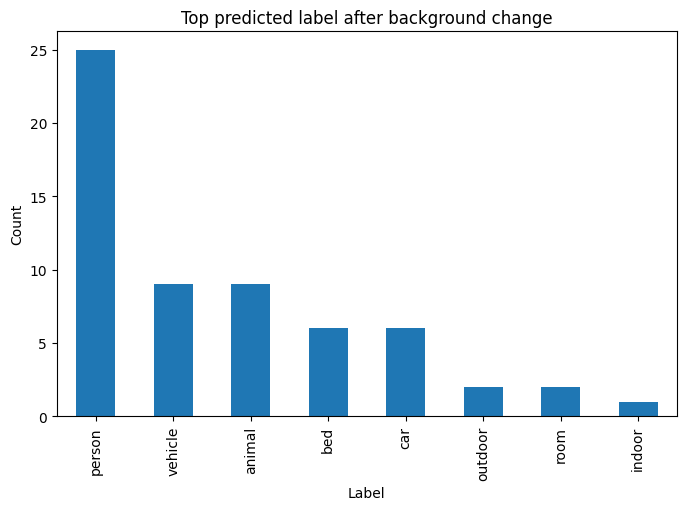

In [ ]:
# DOMINANT LABEL AFTER BG CHANGE

df["top_label"] = df[labels].idxmax(axis=1)

plt.figure(figsize=(8,5))
df["top_label"].value_counts().plot(kind="bar")
plt.title("Top predicted label after background change")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


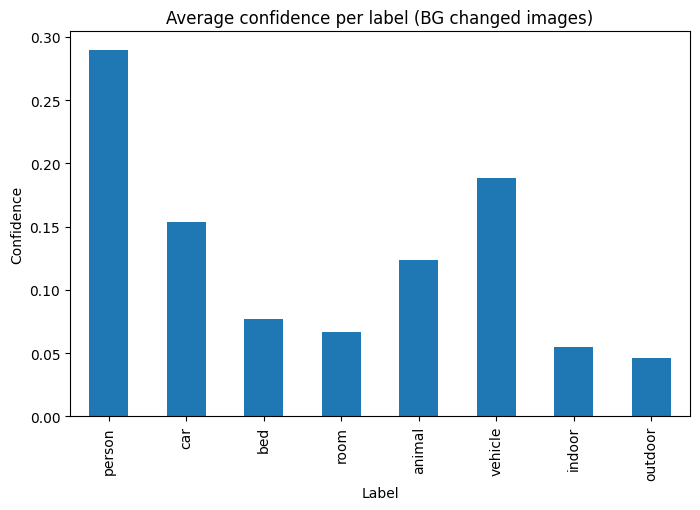

In [ ]:
# AVERAGE CONFIDENCE PER LABEL

mean_conf = df[labels].mean()

plt.figure(figsize=(8,5))
mean_conf.plot(kind="bar")
plt.title("Average confidence per label (BG changed images)")
plt.xlabel("Label")
plt.ylabel("Confidence")
plt.show()


In [ ]:
# STRONGEST BACKGROUND EFFECTS

df["conf_gap"] = df[labels].max(axis=1) - df[labels].min(axis=1)
df.sort_values("conf_gap", ascending=False).head(10)


,id,person,car,bed,room,animal,vehicle,indoor,outdoor,top_label,conf_gap
36,3611,0.988000,0.001439,0.003046,0.004500,0.000336,0.002230,0.000467,0.000369,person,0.987664
57,3957,0.001855,0.946000,0.000158,0.000068,0.001974,0.046360,0.000197,0.003574,car,0.945932
40,2808,0.026840,0.004665,0.001689,0.001057,0.903000,0.005455,0.055940,0.001491,animal,0.901943
33,4375,0.037870,0.063400,0.002617,0.035550,0.013710,0.835400,0.009280,0.002346,vehicle,0.833054
11,2458,0.003454,0.832000,0.003096,0.001139,0.002650,0.151500,0.005350,0.000680,car,0.831320
8,548,0.811000,0.010370,0.006004,0.015570,0.007706,0.132400,0.012120,0.004673,person,0.806327
12,4515,0.791000,0.021410,0.006233,0.027500,0.062900,0.022800,0.063960,0.004025,person,0.786975
38,5574,0.781700,0.017550,0.012054,0.065200,0.072700,0.037140,0.012245,0.001429,person,0.780271
43,54,0.007076,0.017240,0.781000,0.127400,0.003847,0.053130,0.004787,0.005960,bed,0.777153
22,2792,0.765600,0.007053,0.003437,0.014694,0.181900,0.019470,0.006420,0.001325,person,0.764275
